# Relatório da base Bitcoin (Grupo 1)

Este notebook consolida a análise da base `bitcoin` e compara os modelos de séries temporais disponíveis no projeto.

Objetivo: avaliar a qualidade das previsões, identificar a melhor configuração e resumir os principais indicadores para suporte de decisão.

In [6]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import pandas as pd

cwd = Path.cwd().resolve()
project_root = next(
    (path for path in (cwd, *cwd.parents)
     if (path / 'analyses').is_dir() and (path / 'bases').is_dir()),
    None,
)
if project_root is None:
    raise FileNotFoundError('Nao foi possivel localizar a raiz do projeto.')

data_dir = project_root / 'analyses' / 'grupo1' / '01_dados'
results_dir = project_root / 'analyses' / 'grupo1' / '03_resultados'

df = pd.read_csv(data_dir / 'bitcoin_limpo.csv', parse_dates=['date']).sort_values('date')
df.head()

print(f'Linhas: {len(df)}')
print(f"Periodo: {df['date'].min().date()} a {df['date'].max().date()}")
print(f'Colunas: {list(df.columns)}')
print(f'Valores ausentes: {int(df.isna().sum().sum())}')


Linhas: 2943
Periodo: 2018-08-22 a 2026-09-11
Colunas: ['date', 'priceOpen', 'priceHigh', 'priceLow', 'priceClose', 'volume', 'log_priceClose', 'log_volume', 'daily_return', 'daily_range']
Valores ausentes: 1


## 1. Visão geral da série temporal

A base cobre a evolução do preço de fechamento do Bitcoin em vários anos e foi preparada para modelagem com variáveis lagadas, médias móveis, volatilidade, indicadores técnicos e efeitos sazonais.

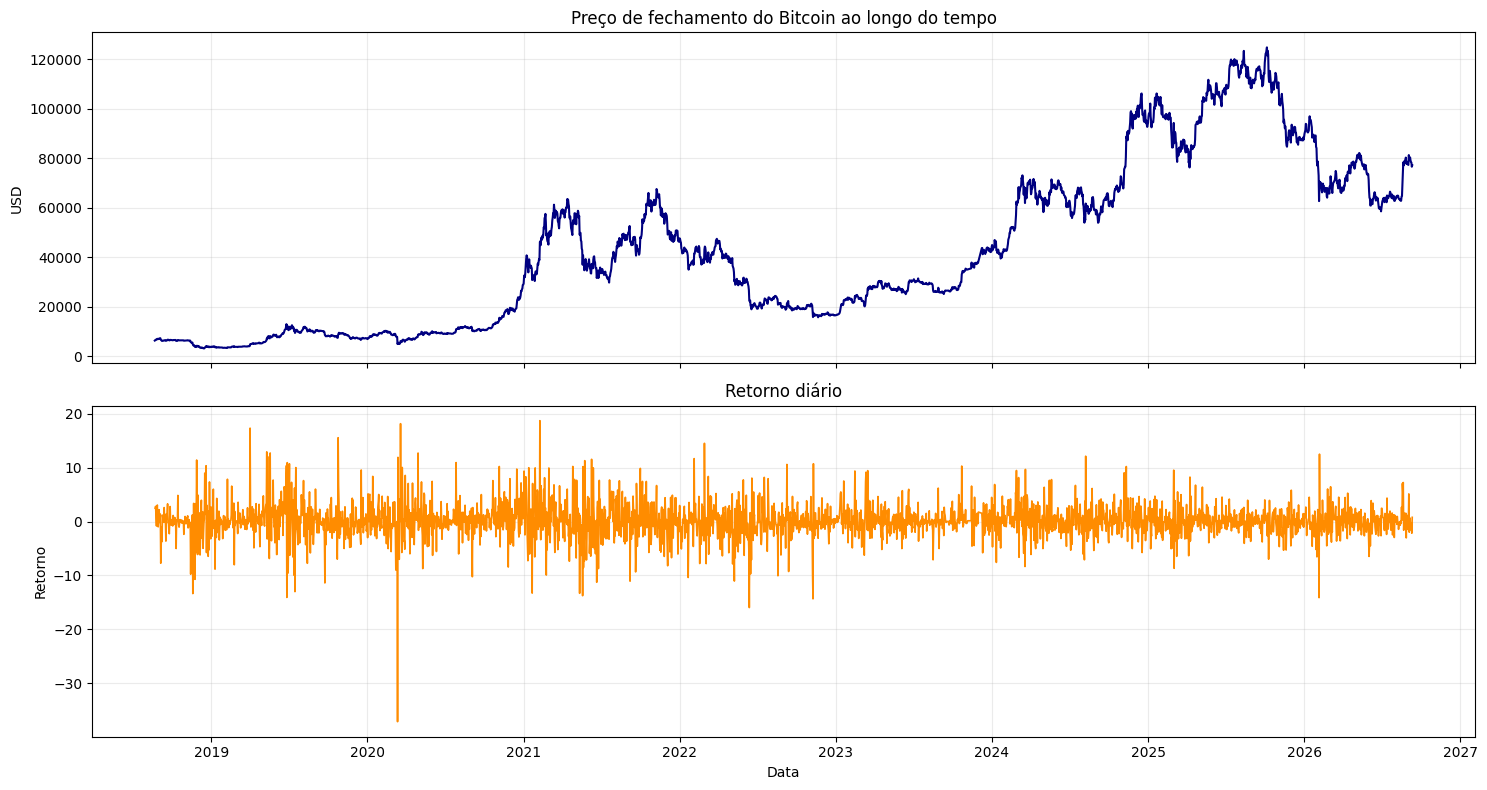

,count,mean,std,min,25%,50%,75%,max
priceClose,2943.0,4.256891e+04,3.241831e+04,3.236762e+03,1.136240e+04,3.537488e+04,6.470159e+04,1.247525e+05
daily_return,2942.0,1.362915e-01,3.190598e+00,-3.716954e+01,-1.266116e+00,5.366246e-02,1.465085e+00,1.874647e+01
daily_range,2943.0,1.672049e+03,1.678032e+03,1.892276e+01,3.891839e+02,1.175315e+03,2.427340e+03,1.792725e+04
volume,2943.0,3.245715e+10,2.133629e+10,3.064030e+09,1.801808e+10,2.838925e+10,4.143101e+10,3.509679e+11


In [7]:
fig, axes = plt.subplots(2, 1, figsize=(15, 8), sharex=True)

axes[0].plot(df['date'], df['priceClose'], color='navy', linewidth=1.5)
axes[0].set_title('Preço de fechamento do Bitcoin ao longo do tempo')
axes[0].set_ylabel('USD')
axes[0].grid(alpha=0.25)

axes[1].plot(df['date'], df['daily_return'], color='darkorange', linewidth=1.2)
axes[1].set_title('Retorno diário')
axes[1].set_ylabel('Retorno')
axes[1].set_xlabel('Data')
axes[1].grid(alpha=0.25)

plt.tight_layout()
plt.show()

df[['priceClose', 'daily_return', 'daily_range', 'volume']].describe().T


## 2. Comparação entre modelos

A comparação abaixo usa o mesmo intervalo de avaliação para todos os modelos disponíveis e reordena o ranking pelo MAE no período comum.

In [8]:
comparison = pd.read_csv(results_dir / 'comparacao_modelos.csv')
comparison = comparison[comparison['status'].eq('Disponivel')].copy()
comparison['MAE_USD'] = pd.to_numeric(comparison['MAE_USD'], errors='coerce')
comparison['RMSE_USD'] = pd.to_numeric(comparison['RMSE_USD'], errors='coerce')
comparison['MAPE_pct'] = pd.to_numeric(comparison['MAPE_pct'], errors='coerce')
comparison['R2'] = pd.to_numeric(comparison['R2'], errors='coerce')
comparison['bias_USD'] = pd.to_numeric(comparison['bias_USD'], errors='coerce')
comparison = comparison.sort_values('MAE_USD').reset_index(drop=True)
comparison[['modelo', 'n_periodo_comum', 'MAE_USD', 'RMSE_USD', 'MAPE_pct', 'R2', 'bias_USD']]


,modelo,n_periodo_comum,MAE_USD,RMSE_USD,MAPE_pct,R2,bias_USD
0,Holt-Winters,856,1406.540849,1963.749080,1.703212,0.989227,2.278829
1,SARIMAX,856,1590.770367,2130.911742,1.899689,0.987315,693.861757
2,Random Forest,856,2108.001665,2901.947396,2.543061,0.976475,240.770865
3,PLS Regression,856,2608.614507,3521.843601,3.157609,0.965351,-336.247160


Melhor modelo por MAE no periodo comum: Holt-Winters
MAE: 1406.54 USD
RMSE: 1963.75 USD
MAPE: 1.70%
R2: 0.9892


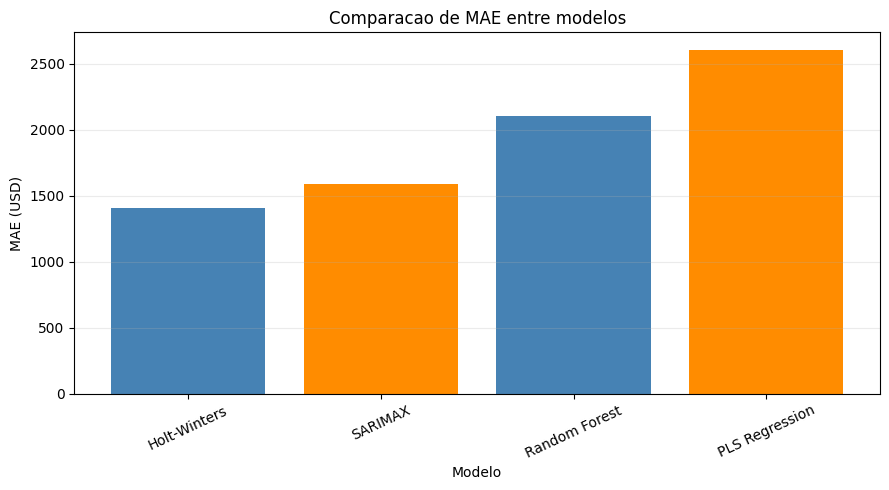

In [9]:
best_model = comparison.iloc[0]
print('Melhor modelo por MAE no periodo comum:', best_model['modelo'])
print(f"MAE: {best_model['MAE_USD']:.2f} USD")
print(f"RMSE: {best_model['RMSE_USD']:.2f} USD")
print(f"MAPE: {best_model['MAPE_pct']:.2f}%")
print(f"R2: {best_model['R2']:.4f}")

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(comparison['modelo'], comparison['MAE_USD'], color=['steelblue', 'darkorange'])
ax.set_title('Comparacao de MAE entre modelos')
ax.set_ylabel('MAE (USD)')
ax.set_xlabel('Modelo')
ax.grid(axis='y', alpha=0.25)
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()


## 3. Fatores relevantes do mercado

Os resultados sugerem que o comportamento recente do preço é altamente influenciado por defasagens do próprio ativo e por indicadores de tendência/volatilidade. Em especial, os termos mais relevantes incluem defasagens de fechamento e médias móveis de curto e médio prazo.

In [10]:
feature_importance = pd.read_csv(results_dir / 'importancia_features_consolidada.csv')
feature_importance.head(10)

top_features = feature_importance.sort_values('PLS_abs', ascending=False).head(10)
top_features[['feature', 'PLS_abs', 'RF_MDI', 'Permutation_Test']]


,feature,PLS_abs,RF_MDI,Permutation_Test
1,close_lag1,0.152633,0.363023,0.039196
2,close_lag2,0.139275,0.054620,0.024547
7,close_lag3,0.127025,0.006771,0.002398
50,close_ma7,0.116919,0.016323,-0.024110
48,close_lag5,0.102689,0.010199,-0.005362
40,close_ma14,0.092521,0.005013,-0.001458
46,close_lag7,0.084848,0.013983,-0.002897
43,close_ma21,0.075930,0.012768,-0.001909
4,close_ma30,0.058133,0.014772,0.002639
23,quarter_cos,0.055734,0.000031,-0.000045


## 4. Conclusão

A avaliação final indica que o melhor modelo para a base foi o **Holt-Winters**, considerando o menor MAE no período comum de comparação. O ranking foi recalculado usando somente datas compartilhadas entre os modelos para garantir comparabilidade justa.

A seguir, os principais indicadores do melhor modelo são exibidos diretamente a partir do arquivo de comparação gerado pelo projeto:

```python
comparison = pd.read_csv(results_dir / 'comparacao_modelos.csv')
best_model = comparison.sort_values('MAE_USD').iloc[0]
display(best_model.to_frame().T[['modelo', 'MAE_USD', 'RMSE_USD', 'MAPE_pct', 'R2', 'bias_USD']])
```

Em termos práticos, o Bitcoin apresenta alta autocorrelação temporal e forte sensibilidade a indicadores de tendência, volatilidade e defasagens próprias do ativo. Esse padrão explica o bom desempenho dos modelos estatísticos e reforça a necessidade de validação walk-forward para evitar overfitting e vazamento temporal.